# Bayesian Neural Network
Dr Claire Villette


Install and import dependencies

In [ ]:
!pip install torch
!pip install torch-uncertainty
!pip install lightning

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torch_uncertainty.models.classification.lenet import bayesian_lenet

import matplotlib.pyplot as plt
import numpy as np
import torchvision
from einops import rearrange

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 74.1 MB/s eta 0:00:00


Load MNIST data

In [ ]:
BATCH_SIZE = 512
MAX_EPOCHS = 2
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

transform = transforms.ToTensor()

train_set = datasets.MNIST(root="data", train=True, download=True, transform=transform)
test_set  = datasets.MNIST(root="data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False)

num_channels = 1
num_classes = 10


Build BNN model

In [ ]:
model = bayesian_lenet(num_channels, num_classes).to(DEVICE)


Define ELBO  (~ loss function)

In [ ]:
class ELBO(nn.Module):
    """
    ELBO = E_q[CrossEntropy] + KL_weight * KL(q||p)
    KL is collected from all stochastic layers inside the model.
    """
    def __init__(self, model, num_samples=3):
        super().__init__()
        self.model = model
        self.num_samples = num_samples
        self.ce = nn.CrossEntropyLoss()

    def forward(self, x, y, kl_weight):
        ce_terms = []


        for _ in range(self.num_samples):
            logits = self.model(x)
            ce_terms.append(self.ce(logits, y))

        ce_avg = torch.stack(ce_terms).mean()

        kl = 0.0
        for m in self.model.modules():
            if hasattr(m, "kl_divergence"):
                kl = kl + m.kl_divergence()

        return ce_avg + kl_weight * kl


loss_fn = ELBO(model, num_samples=3)
optimizer = optim.Adam(model.parameters(), lr=1e-2)


def compute_kl_weight(epoch, max_epochs, warmup=0.3):
    progress = epoch / (max_epochs * warmup)
    return min(1.0, progress) / 10000




Train model

In [ ]:
def train_one_epoch(epoch):
    model.train()
    total_loss = 0
    total = 0
    correct = 0

    kl_weight = compute_kl_weight(epoch, MAX_EPOCHS)

    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()

        loss = loss_fn(x, y, kl_weight)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)

        with torch.no_grad():
            logits = model(x)
            preds = logits.argmax(1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return total_loss / total, correct / total


def test_one_epoch():
    model.eval()
    total = 0
    correct = 0

    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x)

            if logits.size(0) != y.size(0):
                B = y.size(0)
                C = logits.size(1)
                logits = logits.view(B, -1, C).mean(1)

            preds = logits.argmax(1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total


for epoch in range(1, MAX_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(epoch)
    test_acc = test_one_epoch()

    print(f"Epoch {epoch:02d} | "
          f"Loss={train_loss:.4f} | "
          f"Train Acc={train_acc:.4f} | "
          f"Test Acc={test_acc:.4f}")


Epoch 01 | Loss=0.0768 | Train Acc=0.9805 | Test Acc=0.0957
Epoch 02 | Loss=0.0629 | Train Acc=0.9848 | Test Acc=0.0979


Test on handwritten digit images

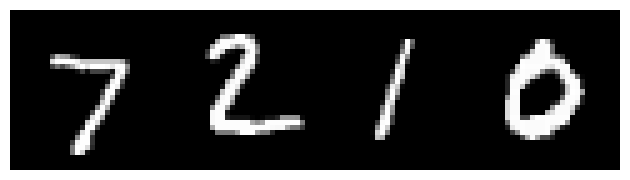

Ground truth: 7 2 1 0
Predicted: 7 2 1 0 7 2 1 0 7 2 1 0 7 2 1 0 7 2 1 0 7 2 1 0 7 2 1 0 7 2 1 0 7 2 1 0 7 2 1 0 7 2 1 0 7 2 1 0 7 2 1 0 7 2 1 0 7 2 1 0 7 2 1 0
Uncertainty (Std over samples): [2.7919968488276936e-06, 8.232852451328654e-06, 2.2136640836833976e-05, 0.0006295100320130587]


In [ ]:
def imshow(img):
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1,2,0)))
    plt.axis("off")
    plt.tight_layout()
    plt.show()

# take 4 images
images, labels = next(iter(test_loader))
images = images[:4].to(DEVICE)
labels = labels[:4]

imshow(torchvision.utils.make_grid(images.cpu()))
print("Ground truth:", " ".join(str(int(x)) for x in labels))

model.eval()

# Collect multiple sample predictions
num_samples = 10
logits_samples = []
with torch.no_grad():
    for _ in range(num_samples):
        logits_samples.append(model(images))

logits = torch.stack(logits_samples)
logits = rearrange(logits, "s b c -> b s c")

probs = torch.softmax(logits, dim=-1)

avg_probs = probs.mean(1)
std_probs = probs.std(1)

preds = avg_probs.argmax(-1)

print("Predicted:", " ".join(str(int(x)) for x in preds.cpu()))
print("Uncertainty (Std over samples):",
      [float(std_probs[i, preds[i]]) for i in range(4)])

Test an image from outside the training domain entirely

In [ ]:
fashion_set  = datasets.FashionMNIST(root="data", train=False, download=True, transform=transform)
fashion_loader  = DataLoader(fashion_set,  batch_size=BATCH_SIZE, shuffle=False)

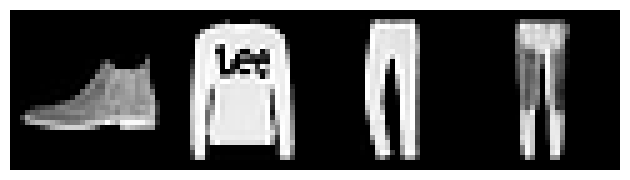

Ground truth: 9 2 1 1
Predicted: 2 4 1 1 2 4 1 1 2 4 1 1 2 4 1 1 2 4 1 1 2 4 1 1 2 4 1 1 2 4 1 1 2 4 1 1 2 4 1 1 2 4 1 1 2 4 1 1 2 4 1 1 2 4 1 1 2 4 1 1 2 4 1 1
Uncertainty (Std over samples): [0.01872892677783966, 0.0017619493883103132, 0.0001460311032133177, 1.5432117379532428e-06]


In [ ]:
# take 4 images
images, labels = next(iter(fashion_loader))
images = images[:4].to(DEVICE)
labels = labels[:4]

imshow(torchvision.utils.make_grid(images.cpu()))
print("Ground truth:", " ".join(str(int(x)) for x in labels))

model.eval()

# Collect multiple posterior samples
num_samples = 10
logits_samples = []
with torch.no_grad():
    for _ in range(num_samples):
        logits_samples.append(model(images))   # stochastic forward pass

logits = torch.stack(logits_samples)  # shape: (S, B, C)
logits = rearrange(logits, "s b c -> b s c")

probs = torch.softmax(logits, dim=-1)

avg_probs = probs.mean(1)
std_probs = probs.std(1)

preds = avg_probs.argmax(-1)

print("Predicted:", " ".join(str(int(x)) for x in preds.cpu()))
print("Uncertainty (Std over samples):",
      [float(std_probs[i, preds[i]]) for i in range(4)])